# A4 - Dataset 1: MNIST

- **Nguồn dữ liệu:** Kaggle CSV.
- **Dạng dữ liệu:** ảnh xám 28×28.
- **Task:** multiclass classification, 10 lớp (0–9).
- **Basic CNN dùng để so sánh công bằng giữa 3 implementation:**  
  `Conv2D -> ReLU -> Conv2D -> ReLU -> MaxPool2D -> Flatten -> Dense(10)`
- **Improved CNN:** nhiều filters hơn + pooling + BatchNorm + Dropout.
- **Metrics:** Accuracy, Precision, Recall, F1, Loss vs Epoch.


> **Phạm vi A4 notebook này bao phủ:** Load dataset → Basic/Discover CNN → Improved CNN → CNN From Scratch → PyTorch → TensorFlow → Train/Evaluate/Compare.
>
> **Lưu ý:** bảng giao bài không quy định cụ thể “Improved CNN” phải dùng kỹ thuật nào. Trong notebook này, bản Improved dùng thêm filters/layer và BatchNorm/Dropout ở framework như một phương án cải tiến hợp lý; phần From Scratch tập trung đúng mục tiêu bài giảng là tự cài convolution, forward/backprop và cập nhật tham số.
>
> Notebook đặt trong `ASignment4/notebooks/`; dữ liệu ở `../data/`, model ở `../models/`, kết quả ở `../results/`.

In [1]:
from pathlib import Path
import random, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

print("Working directory:", Path.cwd())
print("Data directory   :", DATA_DIR.resolve())

Working directory: D:\ASignment4\notebooks
Data directory   : D:\ASignment4\data


## 1. Load và kiểm tra MNIST

In [2]:
train_df = pd.read_csv(DATA_DIR / "mnist_train.csv")
test_df = pd.read_csv(DATA_DIR / "mnist_test.csv")

print("Train:", train_df.shape)
print("Test :", test_df.shape)
display(train_df.head())

def split_mnist(df):
    if "label" in df.columns:
        y = df["label"].to_numpy(dtype=np.int64)
        X = df.drop(columns=["label"]).to_numpy(dtype=np.float32)
    else:
        y = df.iloc[:, 0].to_numpy(dtype=np.int64)
        X = df.iloc[:, 1:].to_numpy(dtype=np.float32)

    assert X.shape[1] == 784, f"Cần 784 pixel, hiện có {X.shape[1]}"
    X = (X / 255.0).reshape(-1, 1, 28, 28)
    return X, y

X_train, y_train = split_mnist(train_df)
X_test, y_test = split_mnist(test_df)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print("Classes:", np.unique(y_train))

Train: (60000, 785)
Test : (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


X_train: (60000, 1, 28, 28) y_train: (60000,)
X_test : (10000, 1, 28, 28) y_test : (10000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


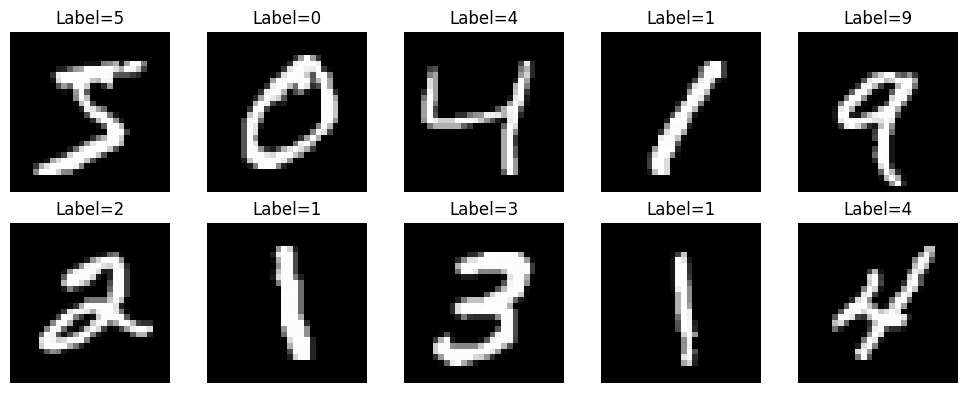

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[i, 0], cmap="gray")
    ax.set_title(f"Label={y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. CNN From Scratch bằng NumPy

Bản Scratch sửa theo kiến trúc **3 trainable layers**:
`Conv1 -> ReLU -> Conv2 -> ReLU -> Pool -> Flatten -> Dense`

Mặc định dùng toàn bộ train set để việc so sánh dữ liệu là nhất quán. Nếu máy quá chậm, có thể đặt `TRAIN_LIMIT` thành một số cụ thể và dùng **cùng giới hạn đó cho cả PyTorch/TensorFlow**.

In [4]:
from numpy.lib.stride_tricks import sliding_window_view

TRAIN_LIMIT = None   # ví dụ 20000 nếu máy chậm; None = toàn bộ

def take_limit(X, y, limit):
    if limit is None or limit >= len(X):
        return X, y
    return X[:limit], y[:limit]

X_fit, y_fit = take_limit(X_train, y_train, TRAIN_LIMIT)

class Conv2DSameManual:
    def __init__(self, in_channels, out_channels, kernel_size=3, seed=42):
        rng = np.random.default_rng(seed)
        self.k = kernel_size
        self.pad = kernel_size // 2
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.W = (rng.standard_normal(
            (out_channels, in_channels, kernel_size, kernel_size)
        ) * scale).astype(np.float32)
        self.b = np.zeros(out_channels, dtype=np.float32)

    def forward(self, x):
        self.x = x
        p = self.pad
        self.xp = np.pad(x, ((0,0),(0,0),(p,p),(p,p)), mode="constant")
        windows = sliding_window_view(self.xp, (self.k, self.k), axis=(2,3))
        return np.einsum("nchwkl,fckl->nfhw", windows, self.W) + self.b[None,:,None,None]

    def backward(self, dout, lr):
        windows = sliding_window_view(self.xp, (self.k, self.k), axis=(2,3))
        dW = np.einsum("nfhw,nchwkl->fckl", dout, windows)
        db = dout.sum(axis=(0,2,3))

        dxp = np.zeros_like(self.xp)
        H, W = dout.shape[2], dout.shape[3]
        for i in range(self.k):
            for j in range(self.k):
                dxp[:,:,i:i+H,j:j+W] += np.einsum(
                    "nfhw,fc->nchw", dout, self.W[:,:,i,j]
                )

        p = self.pad
        dx = dxp[:,:,p:-p,p:-p] if p > 0 else dxp

        self.W -= lr * dW
        self.b -= lr * db
        return dx

class DenseManual:
    def __init__(self, in_dim, out_dim, seed=42):
        rng = np.random.default_rng(seed)
        self.W = (rng.standard_normal((in_dim,out_dim)) * np.sqrt(2.0/in_dim)).astype(np.float32)
        self.b = np.zeros(out_dim, dtype=np.float32)

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout, lr):
        dx = dout @ self.W.T
        dW = self.x.T @ dout
        db = dout.sum(axis=0)
        self.W -= lr * dW
        self.b -= lr * db
        return dx

def relu(x):
    return np.maximum(x, 0)

def softmax_ce(logits, y):
    z = logits - logits.max(axis=1, keepdims=True)
    expz = np.exp(z)
    p = expz / expz.sum(axis=1, keepdims=True)
    n = len(y)
    loss = -np.log(p[np.arange(n), y] + 1e-12).mean()

    d = p.copy()
    d[np.arange(n), y] -= 1
    d /= n
    return float(loss), d


class MaxPool2x2Manual:
    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        H2, W2 = H // 2, W // 2
        x_crop = x[:, :, :H2*2, :W2*2]
        xr = x_crop.reshape(N, C, H2, 2, W2, 2)
        self.maxv = xr.max(axis=(3, 5), keepdims=True)
        self.crop_shape = x_crop.shape
        return self.maxv.squeeze((3, 5))

    def backward(self, dout):
        x = self.x
        N, C, H, W = x.shape
        H2, W2 = H // 2, W // 2
        x_crop = x[:, :, :H2*2, :W2*2]
        xr = x_crop.reshape(N, C, H2, 2, W2, 2)
        mask = xr == self.maxv
        denom = mask.sum(axis=(3, 5), keepdims=True)
        dxr = mask * (dout[:, :, :, None, :, None] / denom)
        dx = np.zeros_like(x)
        dx[:, :, :H2*2, :W2*2] = dxr.reshape(self.crop_shape)
        return dx

class ManualMNISTCNN:
    def __init__(self, seed=42):
        self.conv1 = Conv2DSameManual(1, 4, 3, seed)
        self.conv2 = Conv2DSameManual(4, 8, 3, seed+1)
        self.pool = MaxPool2x2Manual()
        self.fc = DenseManual(8*14*14, 10, seed+2)

    def forward(self, x):
        self.z1 = self.conv1.forward(x)
        self.h1 = relu(self.z1)
        self.z2 = self.conv2.forward(self.h1)
        self.h2 = relu(self.z2)
        self.p = self.pool.forward(self.h2)
        self.pool_shape = self.p.shape
        return self.fc.forward(self.p.reshape(len(x), -1))

    def train_batch(self, x, y, lr):
        logits = self.forward(x)
        loss, dlogits = softmax_ce(logits, y)

        dp = self.fc.backward(dlogits, lr).reshape(self.pool_shape)
        dh2 = self.pool.backward(dp)
        dz2 = dh2 * (self.z2 > 0)
        dh1 = self.conv2.backward(dz2, lr)
        dz1 = dh1 * (self.z1 > 0)
        self.conv1.backward(dz1, lr)
        return loss

    def predict(self, X, batch_size=256):
        out = []
        for s in range(0, len(X), batch_size):
            out.append(np.argmax(self.forward(X[s:s+batch_size]), axis=1))
        return np.concatenate(out)

def train_manual(model, X, y, epochs=3, batch_size=64, lr=0.005):
    rng = np.random.default_rng(SEED)
    hist = []
    for ep in range(epochs):
        order = rng.permutation(len(X))
        losses = []
        for s in range(0, len(X), batch_size):
            b = order[s:s+batch_size]
            losses.append(model.train_batch(X[b], y[b], lr))
        hist.append(float(np.mean(losses)))
        print(f"Epoch {ep+1}/{epochs} - loss={hist[-1]:.4f}")
    return hist

In [5]:
manual_model = ManualMNISTCNN(SEED)
t0 = time.time()
scratch_loss = train_manual(manual_model, X_fit, y_fit, epochs=3, batch_size=64, lr=0.005)
scratch_time = time.time() - t0

scratch_pred = manual_model.predict(X_test)
scratch_acc = accuracy_score(y_test, scratch_pred)
scratch_p, scratch_r, scratch_f1, _ = precision_recall_fscore_support(
    y_test, scratch_pred, average="macro", zero_division=0
)

print(f"Scratch Acc={scratch_acc:.4f} | P={scratch_p:.4f} | R={scratch_r:.4f} | F1={scratch_f1:.4f}")
print(f"Scratch time={scratch_time:.1f}s")

np.savez(
    MODEL_DIR / "mnist_scratch_fixed.npz",
    conv1_W=manual_model.conv1.W, conv1_b=manual_model.conv1.b,
    conv2_W=manual_model.conv2.W, conv2_b=manual_model.conv2.b,
    fc_W=manual_model.fc.W, fc_b=manual_model.fc.b
)

Epoch 1/3 - loss=0.6730
Epoch 2/3 - loss=0.3309
Epoch 3/3 - loss=0.3017
Scratch Acc=0.9155 | P=0.9164 | R=0.9143 | F1=0.9141
Scratch time=338.7s


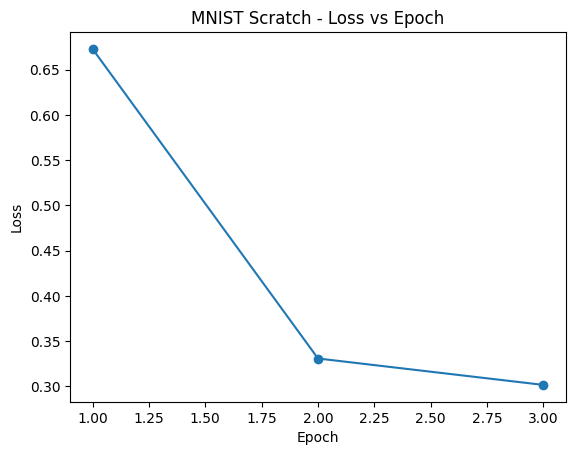

In [6]:
plt.plot(range(1, len(scratch_loss)+1), scratch_loss, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Scratch - Loss vs Epoch")
plt.show()

## 3. PyTorch

**Basic** dùng cùng ý tưởng với Scratch: 2 Conv + Dense.  
**Improved** thêm filters, MaxPool, BatchNorm, Dropout.

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Xpt, ypt = take_limit(X_train, y_train, TRAIN_LIMIT)
train_loader = DataLoader(
    TensorDataset(torch.tensor(Xpt, dtype=torch.float32),
                  torch.tensor(ypt, dtype=torch.long)),
    batch_size=128, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                  torch.tensor(y_test, dtype=torch.long)),
    batch_size=256, shuffle=False
)

class TorchBasic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 4, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(4, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(8*14*14, 10)
        )
    def forward(self, x):
        return self.net(x)

class TorchImproved(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(32*7*7, 10)
        )
    def forward(self, x):
        return self.net(x)

def train_pt(model, epochs=5):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = []

    for ep in range(epochs):
        model.train()
        ls = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            ls.append(loss.item())
        hist.append(float(np.mean(ls)))
        print(f"Epoch {ep+1}/{epochs} - loss={hist[-1]:.4f}")
    return model, hist

def eval_pt(model):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
    pred = np.concatenate(preds)
    acc = accuracy_score(y_test, pred)
    p,r,f1,_ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    return pred, acc, p, r, f1

Device: cpu


In [8]:
pt_basic, pt_basic_loss = train_pt(TorchBasic(), 5)
_, pt_basic_acc, pt_basic_p, pt_basic_r, pt_basic_f1 = eval_pt(pt_basic)

pt_imp, pt_imp_loss = train_pt(TorchImproved(), 5)
_, pt_imp_acc, pt_imp_p, pt_imp_r, pt_imp_f1 = eval_pt(pt_imp)

print("PyTorch Basic   :", pt_basic_acc, pt_basic_f1)
print("PyTorch Improved:", pt_imp_acc, pt_imp_f1)

torch.save(pt_basic.state_dict(), MODEL_DIR / "mnist_pytorch_basic_fixed.pth")
torch.save(pt_imp.state_dict(), MODEL_DIR / "mnist_pytorch_improved_fixed.pth")

Epoch 1/5 - loss=0.4669
Epoch 2/5 - loss=0.1968
Epoch 3/5 - loss=0.1395
Epoch 4/5 - loss=0.1089
Epoch 5/5 - loss=0.0920
Epoch 1/5 - loss=0.1889
Epoch 2/5 - loss=0.0728
Epoch 3/5 - loss=0.0583
Epoch 4/5 - loss=0.0529
Epoch 5/5 - loss=0.0453
PyTorch Basic   : 0.9766 0.9764568929614456
PyTorch Improved: 0.9879 0.9878391215436185


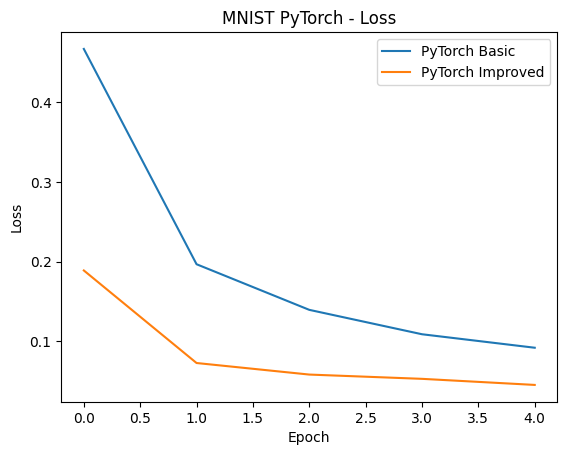

In [9]:
plt.plot(pt_basic_loss, label="PyTorch Basic")
plt.plot(pt_imp_loss, label="PyTorch Improved")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("MNIST PyTorch - Loss")
plt.legend(); plt.show()

## 4. TensorFlow/Keras

In [10]:
import tensorflow as tf
tf.random.set_seed(SEED)

Xtf, ytf = take_limit(X_train, y_train, TRAIN_LIMIT)
Xtf = np.transpose(Xtf, (0,2,3,1))
Xtest_tf = np.transpose(X_test, (0,2,3,1))

def tf_basic_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input((28,28,1)),
        tf.keras.layers.Conv2D(4,3,padding="same",activation="relu"),
        tf.keras.layers.Conv2D(8,3,padding="same",activation="relu"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def tf_improved_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input((28,28,1)),
        tf.keras.layers.Conv2D(16,3,padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(32,3,padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def train_tf(model, epochs=5):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    hist = model.fit(
        Xtf, ytf, validation_split=0.1,
        epochs=epochs, batch_size=128, verbose=2
    )
    return model, hist

In [11]:
tf_basic, tf_basic_hist = train_tf(tf_basic_model(), 5)
tf_imp, tf_imp_hist = train_tf(tf_improved_model(), 5)

tf_basic_pred = np.argmax(tf_basic.predict(Xtest_tf, verbose=0), axis=1)
tf_imp_pred = np.argmax(tf_imp.predict(Xtest_tf, verbose=0), axis=1)

def cls_metrics(pred):
    acc = accuracy_score(y_test, pred)
    p,r,f1,_ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    return acc,p,r,f1

tf_basic_acc,tf_basic_p,tf_basic_r,tf_basic_f1 = cls_metrics(tf_basic_pred)
tf_imp_acc,tf_imp_p,tf_imp_r,tf_imp_f1 = cls_metrics(tf_imp_pred)

print("TF Basic   :", tf_basic_acc, tf_basic_f1)
print("TF Improved:", tf_imp_acc, tf_imp_f1)

tf_basic.save(MODEL_DIR / "mnist_tensorflow_basic_fixed.keras")
tf_imp.save(MODEL_DIR / "mnist_tensorflow_improved_fixed.keras")

Epoch 1/5
422/422 - 2s - 6ms/step - accuracy: 0.8709 - loss: 0.4573 - val_accuracy: 0.9410 - val_loss: 0.2034
Epoch 2/5
422/422 - 2s - 4ms/step - accuracy: 0.9446 - loss: 0.1924 - val_accuracy: 0.9715 - val_loss: 0.1156
Epoch 3/5
422/422 - 1s - 3ms/step - accuracy: 0.9672 - loss: 0.1158 - val_accuracy: 0.9777 - val_loss: 0.0882
Epoch 4/5
422/422 - 1s - 3ms/step - accuracy: 0.9745 - loss: 0.0865 - val_accuracy: 0.9790 - val_loss: 0.0779
Epoch 5/5
422/422 - 1s - 3ms/step - accuracy: 0.9792 - loss: 0.0717 - val_accuracy: 0.9803 - val_loss: 0.0717
Epoch 1/5
422/422 - 7s - 17ms/step - accuracy: 0.9112 - loss: 0.2826 - val_accuracy: 0.9652 - val_loss: 0.1481
Epoch 2/5
422/422 - 6s - 14ms/step - accuracy: 0.9729 - loss: 0.0880 - val_accuracy: 0.9860 - val_loss: 0.0492
Epoch 3/5
422/422 - 7s - 16ms/step - accuracy: 0.9798 - loss: 0.0663 - val_accuracy: 0.9888 - val_loss: 0.0431
Epoch 4/5
422/422 - 7s - 16ms/step - accuracy: 0.9829 - loss: 0.0553 - val_accuracy: 0.9853 - val_loss: 0.0474
Epoch 

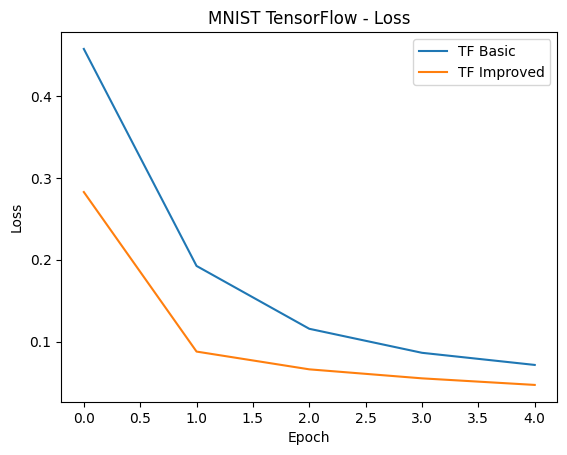

In [12]:
plt.plot(tf_basic_hist.history["loss"], label="TF Basic")
plt.plot(tf_imp_hist.history["loss"], label="TF Improved")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("MNIST TensorFlow - Loss")
plt.legend(); plt.show()

## 5. Bảng so sánh

In [13]:
mnist_results = pd.DataFrame([
    ["NumPy From Scratch","Basic",scratch_acc,scratch_p,scratch_r,scratch_f1],
    ["PyTorch","Basic",pt_basic_acc,pt_basic_p,pt_basic_r,pt_basic_f1],
    ["PyTorch","Improved",pt_imp_acc,pt_imp_p,pt_imp_r,pt_imp_f1],
    ["TensorFlow","Basic",tf_basic_acc,tf_basic_p,tf_basic_r,tf_basic_f1],
    ["TensorFlow","Improved",tf_imp_acc,tf_imp_p,tf_imp_r,tf_imp_f1],
], columns=["Implementation","Model","Accuracy","Precision_macro","Recall_macro","F1_macro"])

display(mnist_results)
mnist_results.to_csv(RESULT_DIR / "mnist_comparison_fixed.csv", index=False)

,Implementation,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,NumPy From Scratch,Basic,0.9155,0.916390,0.914252,0.914150
1,PyTorch,Basic,0.9766,0.976595,0.976434,0.976457
2,PyTorch,Improved,0.9879,0.987828,0.987907,0.987839
3,TensorFlow,Basic,0.9794,0.979374,0.979340,0.979271
4,TensorFlow,Improved,0.9875,0.987609,0.987327,0.987412
